In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [3]:
#data upload and copying
df = pd.read_csv("C:\\Users\\zeynep\\Desktop\\titanic-survival-prediction\\data\\Titanic-Dataset.csv")
df_copy = df.copy() 

In [4]:
#Size of data-columns-Overview. Data types.- numerical properties-null value check 
df_copy.head()
df_copy.shape
df_copy.columns
df_copy.info()
df_copy.describe()
df_copy.isnull().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

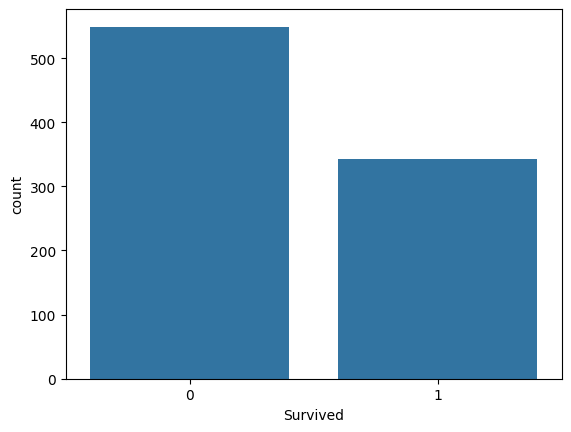

In [5]:
#target distribution-We used a countplot because we were checking for binary distribution.
sns.countplot(x="Survived", data=df_copy)

<Axes: xlabel='Survived', ylabel='count'>

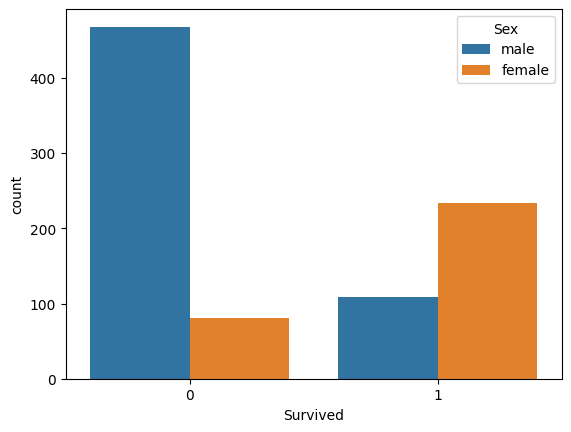

In [6]:
sns.countplot(x="Survived", hue="Sex", data=df_copy) #distribution by gender

Text(0.5, 1.0, 'Survival distribution by Pclass')

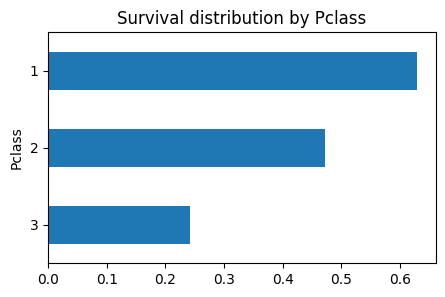

In [7]:
df_copy.groupby("Pclass")["Survived"].mean().sort_values().plot(kind="barh",figsize=(5,3))
plt.title("Survival distribution by Pclass")

Text(0.5, 1.0, 'Survival distribution by Age')

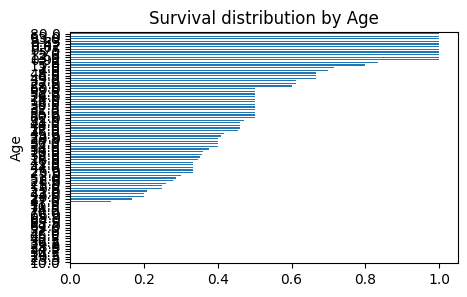

In [8]:
df_copy.groupby("Age")["Survived"].mean().sort_values().plot(kind="barh",figsize=(5,3))
plt.title("Survival distribution by Age")

Text(0.5, 1.0, 'Survival distribution by Embarked')

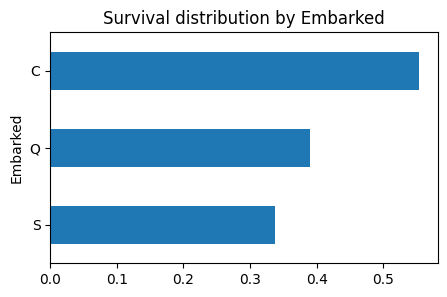

In [8]:
df_copy.groupby("Embarked")["Survived"].mean().sort_values().plot(kind="barh",figsize=(5,3))
plt.title("Survival distribution by Embarked")

<Axes: xlabel='Fare', ylabel='Count'>

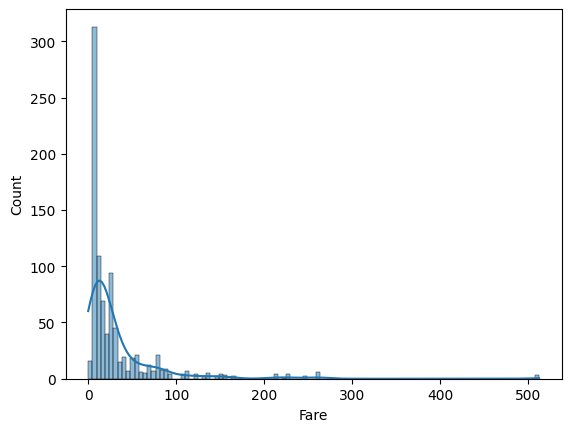

In [9]:
sns.histplot(df["Fare"], kde=True) #main data check for skew to the right

<Axes: xlabel='Fare', ylabel='Count'>

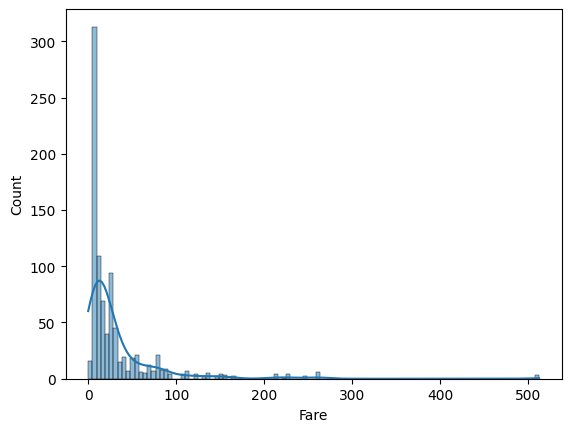

In [10]:
sns.histplot(df_copy["Fare"], kde=True) #If there is a long queue to the right → apply log

In [12]:
df_copy["Fare"] = np.log1p(df_copy["Fare"]) #log transform of skewed numbers


<Axes: xlabel='Fare', ylabel='Count'>

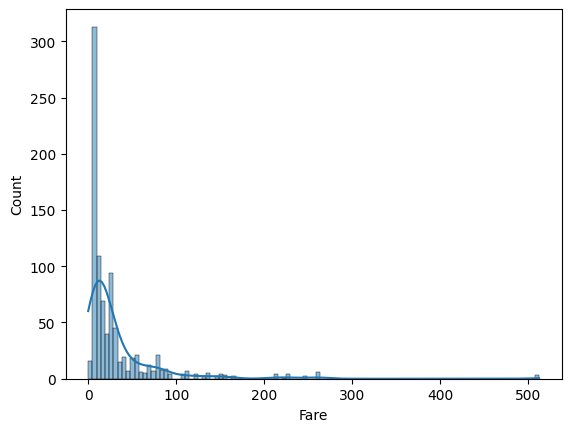

In [10]:
sns.histplot(df_copy["Fare"], kde=True)

In [13]:
corr = df_copy.corr(numeric_only=True)
corr["Survived"].sort_values(ascending=False).head(10) #Correlation analysis is mainly useful for numerical variables. 
#Since many features in this dataset are categorical, additional analysis using grouping and visualization is required to better understand their relationship with the target variable.

Survived       1.000000
Fare           0.329862
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [15]:
df_copy.groupby("Sex")["Survived"].mean() #survivors by gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [16]:
df_copy.groupby(["Pclass","Sex"])["Survived"].mean() #survivors by pclass and gender

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [17]:
df_copy["AgeGroup"] = pd.cut(df_copy["Age"], bins = [0,12,18,35,60,100]) #survivors by age group
df_copy.groupby("AgeGroup")["Survived"].mean()

C:\Users\zeynep koç\AppData\Local\Temp\ipykernel_13032\603552627.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_copy.groupby("AgeGroup")["Survived"].mean()


AgeGroup
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

In [18]:
df_copy.drop(["PassengerId", "Ticket"] , axis=1, inplace=True) #delete unnecessary columns

In [19]:
df_copy.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Cabin', 'Embarked', 'AgeGroup'],
      dtype='object')

In [ ]:
df_copy["Title"] = df_copy["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)#Titles were separated from the name column.

In [ ]:
df_copy["Title"] = df_copy["Title"].replace([
    "Lady", "Countess", "Capt", "Col", "Don", "Dr",
    "Major", "Rev", "Sir", "Jonkheer", "Dona"
], "Rare")#titles were specified

In [ ]:

df_copy.drop(["Name"] , axis=1, inplace=True)#The name column was deleted.

In [23]:
df_copy.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked', 'AgeGroup', 'Title'],
      dtype='object')

In [24]:
df_copy[["Title"]].head()

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr


In [25]:
df_copy["HasCabin"] = df_copy["Cabin"].notnull().astype(int)
df_copy.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked', 'AgeGroup', 'Title', 'HasCabin'],
      dtype='object')

In [27]:
df_copy["HasCabin"] 

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: HasCabin, Length: 891, dtype: int64

In [28]:
df_copy.drop("Cabin", axis=1, inplace=True)

In [ ]:
df_copy.isnull().sum() #missing data

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
AgeGroup    177
Title         0
HasCabin      0
dtype: int64